# Лабораторна робота 2

Виявлення шахрайських транзакцій і вибір порога за вартістю помилок.

Notebook використовує ті самі функції, що й Python скрипти. За замовчуванням він читає збережені прогнози; за потреби модель можна навчити тут на `creditcard.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from IPython.display import Image, display

from analyze_thresholds import (
    add_cost,
    brute_force_table,
    check_toy_sets,
    choose_best,
    counts,
    save_curves,
    save_errors,
    sorted_candidates,
)
from lab2_starter import (
    load_predictions,
    make_splits,
    save_run,
    split_summary,
    train_once,
)

out = Path('results')
data = load_predictions(out)
split_summary(data)

,split,n,positives,positive_fraction
0,train,170884,295,0.001726
1,validation,56961,98,0.001720
2,test,56962,99,0.001738


## Навчання моделі

Для звичайного перегляду notebook використовує результати в `results`. Щоб повторно навчити модель з `creditcard.csv`, розкоментуй два останні рядки в клітинці нижче. Нові ваги та прогнози збережуться в `notebook_results`.

In [ ]:
def train_from_csv(csv_path='../creditcard.csv', output='notebook_results'):
    csv_path = Path(csv_path)
    output = Path(output)
    if output.exists() and any(output.iterdir()):
        raise FileExistsError(f'{output} is not empty; choose another output folder')
    train, validation, test, scaler = make_splits(csv_path)
    output.mkdir(parents=True, exist_ok=True)
    model = train_once(train)
    saved = save_run(output, model, (train, validation, test), scaler, csv_path)
    summary = split_summary(saved)
    summary.to_csv(output / 'split_summary.csv', index=False)
    print(summary.to_string(index=False))
    return output

# Для повторного навчання розкоментуй ці два рядки.
# out = train_from_csv()
# data = load_predictions(out)

## Поділ даних

In [2]:
summary = split_summary(data)
display(summary)
print('Ознаки: V1 ... V28, Amount')
print('Модель: Linear(29, 32) -> ReLU -> Linear(32, 1)')

,split,n,positives,positive_fraction
0,train,170884,295,0.001726
1,validation,56961,98,0.001720
2,test,56962,99,0.001738


Ознаки: V1 ... V28, Amount
Модель: Linear(29, 32) -> ReLU -> Linear(32, 1)


## Пошук порога на validation

In [3]:
y_validation = data['validation_y']
s_validation = data['validation_scores']
candidates = sorted_candidates(y_validation, s_validation)
best = choose_best(candidates)
threshold = float(best['threshold'])

comparison = pd.DataFrame([
    {'rule': 'standard', **add_cost(counts(y_validation, s_validation, 0.5))},
    {'rule': 'minimum_cost', **best.to_dict()},
    {'rule': 'all_negative', **add_cost(counts(y_validation, s_validation, float('inf')))},
])
display(comparison)
print('t* =', threshold)
print('ROC-AUC =', roc_auc_score(y_validation, s_validation))

,rule,threshold,tp,fp,fn,tn,cost
0,standard,0.500000,71.0,9.0,27.0,56854.0,279.0
1,minimum_cost,0.031194,82.0,34.0,16.0,56829.0,194.0
2,all_negative,inf,0.0,0.0,98.0,56863.0,980.0


t* = 0.03119388222694397
ROC-AUC = 0.9733178958233664


Вартість рахується як `C = 10 * FN + FP`. За однакової вартості вибирається більший поріг.

In [4]:
candidate_file = out / 'validation_threshold_candidates.csv'
candidates.rename(columns={'tp': 'TP', 'fp': 'FP', 'fn': 'FN', 'tn': 'TN', 'cost': 'C'}).to_csv(candidate_file, index=False)
print('Кількість кандидатів:', len(candidates))
display(candidates.head())

Кількість кандидатів: 55945


,threshold,tp,fp,fn,tn,cost
0,inf,0,0,98,56863,980
1,0.999600,2,0,96,56863,960
2,0.999264,3,0,95,56863,950
3,0.998837,4,0,94,56863,940
4,0.998725,5,0,93,56863,930


## Графіки та перевірка toy-наборів

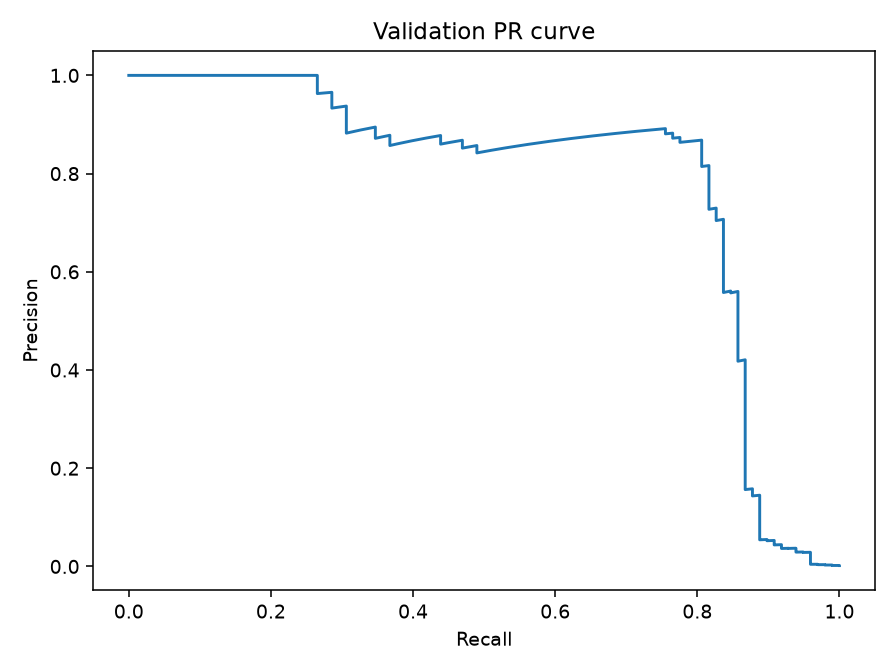

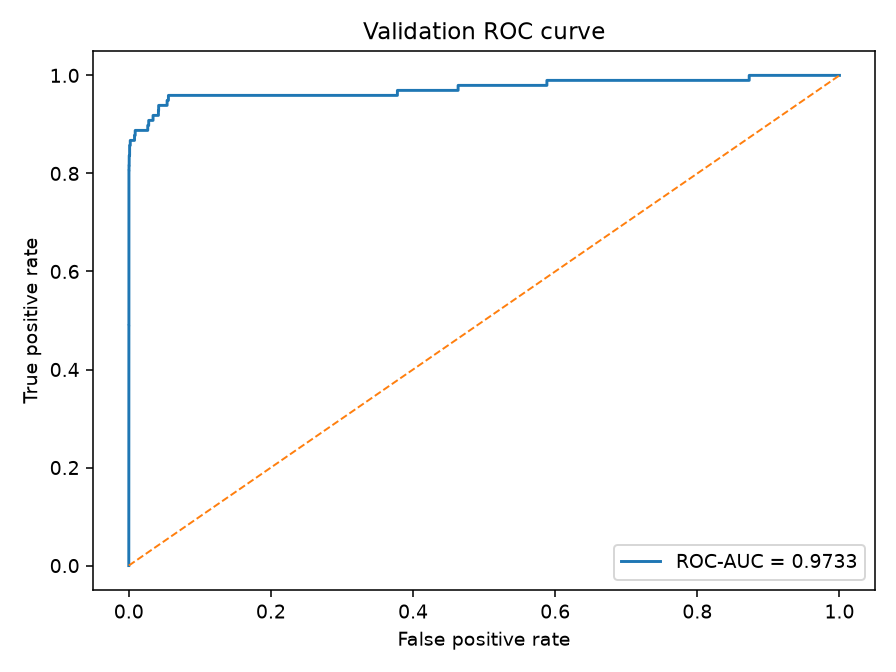

,set,selected_threshold,tp,fp,fn,tn,cost,counters_match,selected_match
0,A,0.4,2,2,0,2,2,True,True
1,B,inf,0,0,0,3,0,True,True
2,C,0.8,1,0,1,11,10,True,True


In [5]:
save_curves(out, y_validation, s_validation)
display(Image(filename=str(out / 'validation_pr.png')))
display(Image(filename=str(out / 'validation_roc.png')))

toy_summary, toy_details = check_toy_sets()
display(toy_summary)
assert toy_summary['selected_match'].all()

## Результат на test

In [6]:
test_counts = add_cost(counts(data['test_y'], data['test_scores'], threshold))
test_counts['precision'] = test_counts['tp'] / (test_counts['tp'] + test_counts['fp'])
test_counts['recall'] = test_counts['tp'] / (test_counts['tp'] + test_counts['fn'])
print(test_counts)

_, selected_errors = save_errors(
    out, data['test_row_ids'], data['test_y'], data['test_scores'],
    data['test_amount'], threshold
)
display(selected_errors)

{'threshold': 0.03119388222694397, 'tp': 80, 'fp': 43, 'fn': 19, 'tn': 56820, 'cost': 233, 'precision': 0.6504065040650406, 'recall': 0.8080808080808081}


,csv_row,error,label,score,amount,distance_from_threshold
5,10497,FN,1,0.011464,3.79,0.019730
6,52521,FN,1,0.006373,105.99,0.024821
7,55401,FN,1,0.005642,1.00,0.025552
8,91671,FN,1,0.000500,290.18,0.030693
9,93486,FN,1,0.018352,0.00,0.012842
0,460,FP,0,0.196159,2.00,0.164965
1,2961,FP,0,0.080961,2.49,0.049767
2,10783,FP,0,0.966327,89.99,0.935133
3,13405,FP,0,0.932032,89.99,0.900838
4,13617,FP,0,0.922762,89.99,0.891568


Висновок: поріг `t*` нижчий за 0.5, тому модель знаходить більше шахрайських транзакцій, але дає більше хибних тривог. Вартість на validation зменшується, бо пропущене шахрайство у 10 разів дорожче за FP.